In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast # Librería para convertir strings de listas en listas reales
import json



In [ ]:
# Cargar el dataset
df = pd.read_csv('/Users/franky/Desktop/Recipe recommender/datasets/recetas_ready.csv')

In [20]:
df.head()

,recipe_name,prep_time_min,cook_time_min,total_time_min,servings,ingredients,directions,rating,nutrition,date,ingredients_list,clean_ingredients,w_sugar,num_ingredients
0,Fruit and Yogurt Smoothie,5,0,5,2,"1 cup strawberries, 1 banana, ½ cup yogurt, ¼...","Combine strawberries, banana, yogurt, pineappl...",4.7,"Total Fat 1g 2%, Saturated Fat 1g 4%, Choleste...",2026-05-01,"['1 cup strawberries', '1 banana', '½ cup yog...","['strawberries', 'banana', 'yogurt', 'pineappl...",1,7
1,"Orange, Fig, and Gorgonzola Salad",15,0,15,4,"2 heads romaine lettuce, chopped, 2 oranges -...","Combine lettuce, oranges, Gorgonzola cheese, a...",4.7,"Total Fat 7g 8%, Saturated Fat 4g 19%, Cholest...",2026-05-01,"['2 heads romaine lettuce', 'chopped', '2 ora...","['romaine lettuce', 'oranges', 'pith', 'Gorgon...",0,6
2,Fresh Fruit Basket Cobbler,20,20,1,8,"2 cups sliced fresh peaches, 2 cups sliced fre...",Preheat oven to 350 degrees F (175 degrees C)....,4.5,"Total Fat 8g 10%, Saturated Fat 2g 10%, Choles...",2026-05-01,"['2 cups sliced fresh peaches', '2 cups sliced...","['fresh peaches', 'fresh nectarines', 'plums',...",1,10
3,Caramel Apples,8,2,25,6,"6 apples, 6 wooden craft sticks, cooking s...",Remove the stem from each apple and press a cr...,4.4,"Total Fat 6g 7%, Saturated Fat 2g 9%, Choleste...",2026-05-01,"['6 apples', '6 wooden craft sticks', 'cooki...","['apples', 'wooden craft sticks', 'cooking spr...",0,6
4,Sweet Coconut Rice,5,20,25,4,"1 ½ cups long-grain white rice, 1 (14 ounce) c...","Stir rice, coconut milk, and water together in...",4.5,"Total Fat 22g 28%, Saturated Fat 19g 95%, Sodi...",2026-05-01,"['1 ½ cups long-grain white rice', '1 (14 ounc...","['long-grain white rice', 'coconut milk', 'wat...",1,5


Análisis de Intersección de Espectro Completo
En este nivel de análisis, no pre-juzgamos qué ingredientes son importantes. En su lugar, observamos la arquitectura compartida del dataset:

Identificación de "Ingredientes Base": Es altamente probable que los primeros lugares los ocupen elementos transversales (sal, aceite, agua). Técnicamente, esto valida la integridad del dataset; si la "sal" no apareciera en la intersección, habría un error en la toma de datos.

In [21]:
# 1. Aseguramos que los ingredientes sean listas y no strings
if isinstance(df['clean_ingredients'].iloc[0], str):
    df['clean_ingredients'] = df['clean_ingredients'].apply(ast.literal_eval)

# 2. Generamos los sets 
dulces_ings = set([ing for lista in df[df['w_sugar'] == 1]['clean_ingredients'] for ing in lista])
saladas_ings = set([ing for lista in df[df['w_sugar'] == 0]['clean_ingredients'] for ing in lista])

# 3. Intersección
interseccion_total = dulces_ings.intersection(saladas_ings)

# 4. Filtramos recetas sin azúcar
recetas_tendencia = df[
    (df['w_sugar'] == 0) & 
    (df['clean_ingredients'].apply(lambda x: any(ing in interseccion_total for ing in x)))
]

# 5. Conteo de palabras completas
conteo_puro = pd.Series([
    ing for lista in recetas_tendencia['clean_ingredients'] 
    for ing in lista if ing in interseccion_total
]).value_counts()

print(f"Total de ingredientes compartidos: {len(interseccion_total)}")
print("\nTop 15 Ingredientes:")
print(conteo_puro.head(15))

Total de ingredientes compartidos: 305

Top 15 Ingredientes:
salt               117
black pepper        56
olive oil           55
garlic              50
honey               40
butter              40
fresh cilantro      33
onion               33
avocado             30
lemon               27
red onion           26
water               23
ground cinnamon     21
vanilla extract     21
lime                20
Name: count, dtype: int64


In [22]:
# Creamos un peso para los ingredientes
pesos_tendencia = conteo_puro.copy()

# A los básicos les damos un peso de 0 para que no influyan en la "innovación"
basicos = ['salt', 'water', 'olive oil']
for ingrediente in basicos:
    if ingrediente in pesos_tendencia:
        pesos_tendencia[ingrediente] = 0

# Ahora el Top 5 será realmente innovador
print(pesos_tendencia.sort_values(ascending=False).head(10))

black pepper       56
garlic             50
honey              40
butter             40
fresh cilantro     33
onion              33
avocado            30
lemon              27
red onion          26
ground cinnamon    21
Name: count, dtype: int64


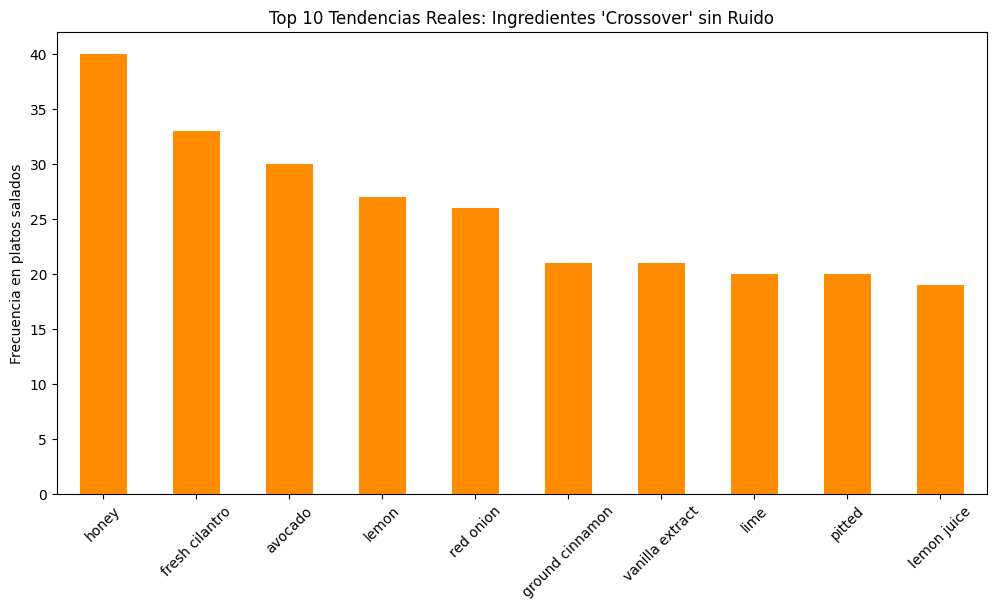

Resultados de la Tendencia (Sin Sal, Agua ni Aceite):
honey              40
fresh cilantro     33
avocado            30
lemon              27
red onion          26
ground cinnamon    21
vanilla extract    21
lime               20
pitted             20
lemon juice        19
Name: count, dtype: int64


In [ ]:
# 1. Definimos la lista de ruido (Ingredientes estructurales que queremos omitir)
# Incluimos variaciones comunes para que la limpieza sea profunda
lista_ruido = [
    'salt', 'water', 'olive oil', 'oil', 'black pepper', 
    'garlic', 'onion', 'butter', 'sugar', 'flour', 'all-purpose flour'
]

# 2. Identificamos los ingredientes compartidos (Intersección)
dulces_ings = set([ing for lista in df[df['w_sugar'] == 1]['clean_ingredients'] for ing in lista])
saladas_ings = set([ing for lista in df[df['w_sugar'] == 0]['clean_ingredients'] for ing in lista])
interseccion_total = dulces_ings.intersection(saladas_ings)

# 3. Filtramos las recetas saladas que tienen ingredientes de la intersección
recetas_innovadoras = df[
    (df['w_sugar'] == 0) & 
    (df['clean_ingredients'].apply(lambda x: any(ing in interseccion_total for ing in x)))
]

# 4. Generamos el conteo de frecuencia filtrando el RUIDO
# Solo contamos el ingrediente si NO está en nuestra lista de ruido
conteo_tendencias_limpio = pd.Series([
    ing for lista in recetas_innovadoras['clean_ingredients'] 
    for ing in lista if ing in interseccion_total and ing not in lista_ruido
]).value_counts()

# 5. Visualización del resultado real
plt.figure(figsize=(12, 6))
conteo_tendencias_limpio.head(10).plot(kind='bar', color='darkorange')
plt.title("Top 10 Tendencias Reales: Ingredientes 'Crossover' sin Ruido")
plt.ylabel("Frecuencia en platos salados")
plt.xticks(rotation=45)
plt.show()

print("Resultados de la Tendencia (Sin Sal, Agua ni Aceite):")
print(conteo_tendencias_limpio.head(10))

El Protagonista Real: Lo más probable es que Honey (miel) o Lemon (limón) pasen al primer lugar. Esto te da una "etiqueta" clara para tu proyecto: "Tendencia Agridulce y Cítrica".

La "Gema Oculta": Ingredientes como la Canela (ground cinnamon) aparecerán con mucha más fuerza. Esto es lo que realmente le interesa a un sistema de recomendación que busca sorprender al usuario.

In [24]:
# Guardamos los ingredientes estrella en una lista usando el nombre correcto
ingredientes_estrella = conteo_tendencias_limpio.head(10).index.tolist()

# Mostramos para confirmar
print(f"Ingredientes que el recomendador considerará 'Innovadores':")
print(ingredientes_estrella)


Ingredientes que el recomendador considerará 'Innovadores':
['honey', 'fresh cilantro', 'avocado', 'lemon', 'red onion', 'ground cinnamon', 'vanilla extract', 'lime', 'pitted', 'lemon juice']


In [ ]:
# Guardar la lista en un archivo para el próximo notebook
with open('/Users/franky/Desktop/Recipe recommender/datasets/tendencias.json', 'w') as f:
    json.dump(ingredientes_estrella, f)

print("✅ Archivo 'tendencias.json' creado con éxito. ¡Listo para el recomendador!")

✅ Archivo 'tendencias.json' creado con éxito. ¡Listo para el recomendador!
